In [1]:
import torch

torch.cuda.empty_cache()

In [2]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
torch.manual_seed(17)

random.seed()



In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
numerical_x = torch.Tensor(2000, 2).uniform_(-3, 3).float()
numerical_x = numerical_x.to(device)  

In [6]:
def checkSMTconstraints(vars,a_learnt,divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """ Check the SMT constraints for the given variables and learnt parameters. """
    ball = Expression(0)

    # # construct ball constraint
    # for i in range(len(vars)):
    #     ball += vars[i]**2
    # ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)

    # construct a box constraint that |var_i| <= ball_ub for all i
    box_constraints = []
    for i in range(len(vars)):
        box_constraints.append(logical_and(vars[i] >= -ball_ub, vars[i] <= ball_ub))
    ball_in_bound = logical_and(*box_constraints)

    # condition on a
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )

    # check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)


def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor

In [7]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x):
    v = 2.0
    L = 1.0
    radius = 10.0  # curvature for unit circle
    de = x[0]
    theta_e = x[1]
    coef = radius / v
    denom = coef - torch.sin(theta_e) 
    return torch.tensor([
        v * torch.sin(theta_e),
        -1 *  torch.cos(theta_e) / denom
    ], device=device)

def g(x):
    v = 2.0
    L = 1.0
    radius = 10.0  # curvature for unit circle
    return torch.tensor([
        0.0,
        v / L
    ], device=device)




In [8]:
class polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)  # set bias to zero
                layer.bias.requires_grad = False  # freeze bias to stay zero


    def forward(self, x):
        return self.net(x)
    
class numerator_polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class FixedDenominatorNet(nn.Module):
    def __init__(self):
        super(FixedDenominatorNet, self).__init__()

    def forward(self, x):
        # Compute e^{||x||^2}
        norm_squared = torch.sum(x ** 2, dim=1, keepdim=True)  
        return torch.exp(norm_squared)
     
class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias



In [9]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad


def gradient_at_given_function_special_b(func, x):
    """
    This function returns the gradient of f^T f at x.
    Here, f: R^n → R^d, and we wish to return the gradient of f^T f at x.
    
    The idea:
    - Compute output = f(x), which is a vector in R^d.
    - Compute squared norm: output_norm_squared = ||f(x)||^2 = f^T f.
    - Compute gradient of output_norm_squared w.r.t. x.
    """
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
    # Compute f(x)
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Remove batch dimension to get shape [d]
    output = output.squeeze(0)
    
    # Check that output is a vector (1D)
    if output.dim() != 1:
        raise ValueError(f"The function must return a vector value (shape [d]), but got shape {output.shape}.")
    
    # Compute f^T f = ||f(x)||^2
    output_norm_squared = torch.sum(output ** 2)
    
    # Compute the gradient w.r.t. x
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    
    return grad



def div_f(x):
    # x[0] = d_e, x[1] = theta_e
    v = 2  # choose your vehicle speed
    radius = 10  # curvature of path (for unit circle, kappa=1/R=1)
    divergence = (v * radius* torch.sin(x[1])-(v**2)) / ((radius-v*torch.sin(x[1]))**2)
    return divergence

def div_g(x):
    return torch.tensor(0.0, device=device)


def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    ret_val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        divergence_at_g = div_g(x[i])
        grad_at_a = gradient_at_given_function(a_fun, x[i])
        grad_at_c = gradient_at_given_function(c_fun, x[i])
        grad_at_b = gradient_at_given_function_special_b(b_fun, x[i])
        # square root of x^Tx
        
        a_vals = a_fun(x[i])
        # b_vals = b_fun(x[i])
        c_vals = c_fun(x[i])
        f_vals = f_fun(x[i])
        g_vals = g_fun(x[i])
        term1 = a_vals * divergence_at_f + divergence_at_g * c_vals + grad_at_a.T @ f_vals + grad_at_c.T @ g_vals
        term2 = (2 * x[i] + grad_at_b) @ (f_vals * a_vals + g_vals * c_vals)
        term = term1 - term2
        ret_val.append(term)
    ret_val = torch.stack(ret_val)
    return ret_val 



In [10]:
def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun, lambda_center=1, lambda_decay=1):
    """
    Compute the control density loss with additional center and decay regularization.

    Args:
        x: Input tensor.
        f_fun: Function representing f(x).
        g_fun: Function representing g(x).
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).
        gamma_fun: Function representing gamma(x).
        lambda_center: Weight for center-maximizing term.
        lambda_decay: Weight for decay-penalizing term.

    Returns:
        Total control density loss value.
    """
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(gamma_fun(x) - divergence).mean()
    a_loss = F.relu(-a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
      
    total_loss = loss + a_loss + gamma_loss 
    return total_loss


In [11]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [12]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [13]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    # b_sym = ||b_sym||^2
    b_sym = sum([bi**2 for bi in b_sym])


    # write f and g in terms of val
    v = 2.0
    L = 1.0
    radius = 10.0  # curvature for unit circle

    f_val = [
        v * sin(vars[1]),
        - v *  cos(vars[1]) / (radius - v*sin(vars[1]))
    ]
    g_val = [
        0,
        v / L
    ]

    f_div = (v * radius* sin(vars[1])-(v**2)) / ((radius-v*sin(vars[1]))**2)
    g_div = 0



    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [325]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 3
x1 = Variable("x1")
x2 = Variable("x2")


In [326]:
def train_density(x,epochs=2000, lr=1e-2):
    loss_total_density = []
    # Define the neural networks
    a_net = numerator_polynomial_net(2, 12, 1).to(device)
    c_net = polynomial_net(2, 12, 1).to(device)
    b_net = polynomial_net_bias_Zero(2, 12, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)

    # Define the optimizer
    optimizer = torch.optim.RMSprop(list(a_net.parameters()) + list(c_net.parameters()) + list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr)

    valid = False
    print("Training density function")
    while not valid :
        for epoch in range(epochs):
            optimizer.zero_grad()
            # compute the loss
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            # backpropagation
            loss.backward()
            # update the parameters
            optimizer.step()
            
            if loss.item() == 0:
                # # Check for counterexamples
                # vars = [Variable("x1"), Variable("x2")]
                # a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                # CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                # if (CE):
                #     print("Counterexample found!")
                #     x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                # else:
                valid = True 
                print("No counterexample found.")
                break

            if loss.item() < 5e-3:
                valid = True
                break

            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if epoch % 100 == 0:
                # Check for counterexamples
                vars = [Variable("x1"), Variable("x2")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
    print(f"Final Loss: {loss.item():.4f}")
    print(f"The learned margin is {gamma_net(torch.tensor([0,0], dtype=torch.float32, device=device))}")
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [327]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [328]:
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-3)

Training density function


Epoch 0/2000, Loss: 1.1615
Counterexample found!
Epoch 1/2000, Loss: 0.5071
Epoch 2/2000, Loss: 0.3024
Epoch 3/2000, Loss: 0.1247
Epoch 4/2000, Loss: 0.0328
Epoch 5/2000, Loss: 0.0260
Epoch 6/2000, Loss: 0.0236
Epoch 7/2000, Loss: 0.0224
Epoch 8/2000, Loss: 0.0209
Epoch 9/2000, Loss: 0.0198
Epoch 10/2000, Loss: 0.0189
Epoch 11/2000, Loss: 0.0181
Epoch 12/2000, Loss: 0.0174
Epoch 13/2000, Loss: 0.0168
Epoch 14/2000, Loss: 0.0163
Epoch 15/2000, Loss: 0.0159
Epoch 16/2000, Loss: 0.0156
Epoch 17/2000, Loss: 0.0154
Epoch 18/2000, Loss: 0.0150
Epoch 19/2000, Loss: 0.0148
Epoch 20/2000, Loss: 0.0146
Epoch 21/2000, Loss: 0.0144
Epoch 22/2000, Loss: 0.0143
Epoch 23/2000, Loss: 0.0144
Epoch 24/2000, Loss: 0.0142
Epoch 25/2000, Loss: 0.0141
Epoch 26/2000, Loss: 0.0139
Epoch 27/2000, Loss: 0.0138
Epoch 28/2000, Loss: 0.0136
Epoch 29/2000, Loss: 0.0135
Epoch 30/2000, Loss: 0.0134
Epoch 31/2000, Loss: 0.0133
Epoch 32/2000, Loss: 0.0131
Epoch 33/2000, Loss: 0.0131
Epoch 34/2000, Loss: 0.0130
Epoch 35

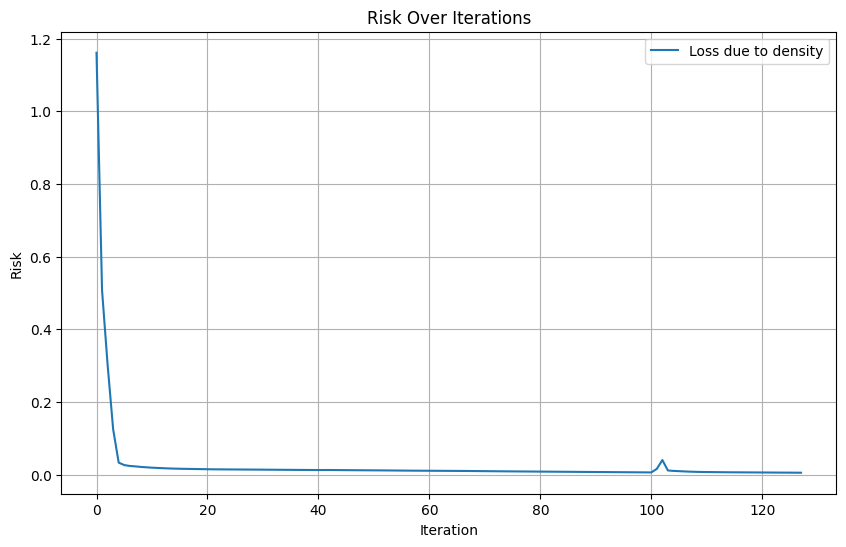

In [329]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [330]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-3, 3, grid_size)
x2 = torch.linspace(-3, 3, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


In [331]:
rho_set = a_ret(grid_points)/ (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)))


# # Compute violations set: element-wise min of rho_set and divergence_set
# violations_set = torch.minimum(rho_set, divergence_set)
violations_set = rho_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)


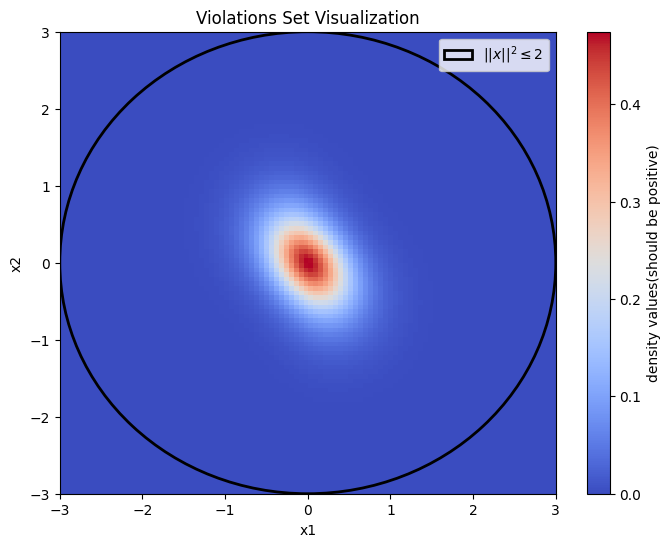

In [332]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="density values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 3, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 2$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


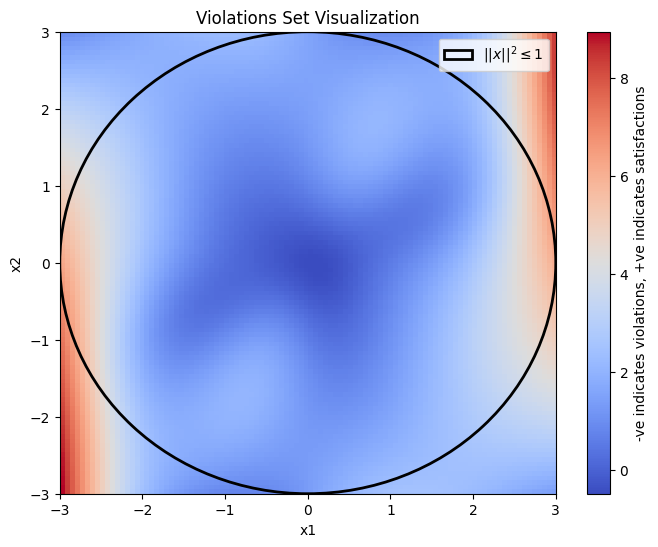

In [333]:
divergence_set = control_density_risk(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = divergence_set
# # # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)




import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="-ve indicates violations, +ve indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 3, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 1$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [334]:
torch.save(a_ret.state_dict(), 'learnt_a_path_tracking_rebuttal.pth')
torch.save(b_ret.state_dict(), 'learnt_b_path_tracking_rebuttal.pth')
torch.save(c_ret.state_dict(), 'learnt_c_path_tracking_rebuttal.pth')

# With new random initialization

In [335]:
# get some fresh data 
torch.manual_seed(7)
random.seed()
numerical_x = torch.Tensor(2000, 2).uniform_(-3, 3).float()
numerical_x = numerical_x.to(device)

loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-3)

Training density function
Epoch 0/2000, Loss: 0.3272
Counterexample found!
Epoch 1/2000, Loss: 0.1670
Epoch 2/2000, Loss: 0.0441
Epoch 3/2000, Loss: 0.0298
Epoch 4/2000, Loss: 0.0237
Epoch 5/2000, Loss: 0.0200
Epoch 6/2000, Loss: 0.0174
Epoch 7/2000, Loss: 0.0157
Epoch 8/2000, Loss: 0.0148
Epoch 9/2000, Loss: 0.0141
Epoch 10/2000, Loss: 0.0133
Epoch 11/2000, Loss: 0.0129
Epoch 12/2000, Loss: 0.0126
Epoch 13/2000, Loss: 0.0122
Epoch 14/2000, Loss: 0.0119
Epoch 15/2000, Loss: 0.0112
Epoch 16/2000, Loss: 0.0109
Epoch 17/2000, Loss: 0.0105
Epoch 18/2000, Loss: 0.0106
Epoch 19/2000, Loss: 0.0102
Epoch 20/2000, Loss: 0.0102
Epoch 21/2000, Loss: 0.0099
Epoch 22/2000, Loss: 0.0098
Epoch 23/2000, Loss: 0.0095
Epoch 24/2000, Loss: 0.0094
Epoch 25/2000, Loss: 0.0092
Epoch 26/2000, Loss: 0.0090
Epoch 27/2000, Loss: 0.0090
Epoch 28/2000, Loss: 0.0089
Epoch 29/2000, Loss: 0.0089
Epoch 30/2000, Loss: 0.0087
Epoch 31/2000, Loss: 0.0085
Epoch 32/2000, Loss: 0.0084
Epoch 33/2000, Loss: 0.0083
Epoch 34/2

In [336]:
torch.save(a_ret.state_dict(), 'learnt_a_path_tracking_2_rebuttal.pth')
torch.save(b_ret.state_dict(), 'learnt_b_path_tracking_2_rebuttal.pth')
torch.save(c_ret.state_dict(), 'learnt_c_path_tracking_2_rebuttal.pth')

In [14]:

# Define model dimensions
INPUT_DIM = 2
HIDDEN_DIM = 12
# Output dimensions based on your original code
A_OUTPUT_DIM = 1
B_OUTPUT_DIM = 2
C_OUTPUT_DIM = 1


In [15]:
# load the trained weights here for u_1 and \rho_1

# Instantiate the models
a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM, A_OUTPUT_DIM).to(device)
b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM, B_OUTPUT_DIM).to(device)
c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM, C_OUTPUT_DIM).to(device)

# Load the state dictionaries from the saved files
# Make sure the .pth files are in the same directory as your notebook, or provide the full path.
try:
    a_net.load_state_dict(torch.load('Models/learnt_a_path_tracking_rebuttal.pth', map_location=device))
    b_net.load_state_dict(torch.load('Models/learnt_b_path_tracking_rebuttal.pth', map_location=device))
    c_net.load_state_dict(torch.load('Models/learnt_c_path_tracking_rebuttal.pth', map_location=device))
    print("Successfully loaded all model weights.")
except FileNotFoundError as e:
    print(f"Error loading model weights: {e}")
    print("Please make sure the .pth files are in the correct directory.")
    # Exit or handle the error appropriately
    exit()

Successfully loaded all model weights.


/tmp/ipykernel_775964/4243264965.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Models/learnt_a_path_tracking_rebuttal.pth', map_loca

In [16]:

# Set models to evaluation mode. This is important for inference.
a_net.eval()
b_net.eval()
c_net.eval()


polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): Tanh()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): Tanh()
    (4): Linear(in_features=12, out_features=12, bias=True)
    (5): Tanh()
    (6): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [17]:
# load the trained weights here for u_1 and \rho_1

# Instantiate the models
a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM, A_OUTPUT_DIM).to(device)
b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM, B_OUTPUT_DIM).to(device)
c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM, C_OUTPUT_DIM).to(device)

# Load the state dictionaries from the saved files
# Make sure the .pth files are in the same directory as your notebook, or provide the full path.
try:
    a_net1.load_state_dict(torch.load('Models/learnt_a_path_tracking_2_rebuttal.pth', map_location=device))
    b_net1.load_state_dict(torch.load('Models/learnt_b_path_tracking_2_rebuttal.pth', map_location=device))
    c_net1.load_state_dict(torch.load('Models/learnt_c_path_tracking_2_rebuttal.pth', map_location=device))
    print("Successfully loaded all model weights.")
except FileNotFoundError as e:
    print(f"Error loading model weights: {e}")
    print("Please make sure the .pth files are in the correct directory.")
    # Exit or handle the error appropriately
    exit()



Successfully loaded all model weights.


/tmp/ipykernel_775964/1361041624.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net1.load_state_dict(torch.load('Models/learnt_a_path_tracking_2_rebuttal.pth', map_l

# Combined Controllers


/tmp/ipykernel_775964/1551767518.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


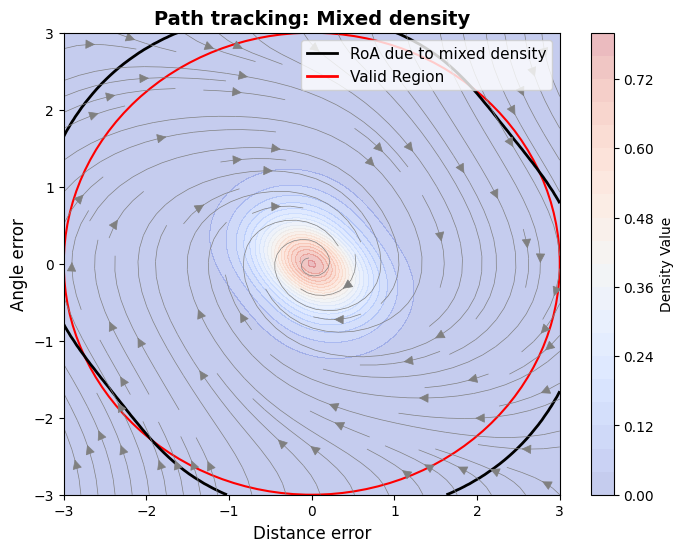

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path tracking: Mixed density'}, xlabel='Distance error', ylabel='Angle error'>)

In [18]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-3, 3, 100)
    x2 = torch.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 = a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-3, 3, 20)
        x2_flow = np.linspace(-3, 3, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho_set2 = a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho_set1 = rho_set1 / max(rho_set1)  
            rho_set2 = rho_set2 / max(rho_set2)
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 3, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Mixed density', fontsize=14, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='-', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
   
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 1e-6, device, plot_flow=True)



# Yang et al

comparaison with yang et al

In [19]:
import math
import typing
from typing import Optional, Union

In [20]:

class NeuralNetworkLyapunov(nn.Module):
    """
    V(x) = V_nominal(x) + network_output(x) + V_psd_output(x)
    V_nominal(x) contains NO optimizable parameters.
    network_output =
    ϕ(x) − ϕ(x*) if absolute_output = False
    |ϕ(x) − ϕ(x*)| if absolute_output = True
    V_psd_output =
    |(εI+RᵀR)(x-x*)|₁ if V_psd_form = "L1"
    (x-x*)ᵀ(εI+RᵀR)(x-x*) if V_psd_form = "quadratic".
    |R(x-x*)|₁ if V_psd_form = "L1_R_free"

    The optimizable parameters are the network ϕ and R.
    """

    def __init__(
        self,
        goal_state: torch.Tensor,
        hidden_widths: list,
        x_dim: int,
        R_rows: int,
        absolute_output: bool,
        eps: float,
        activation: nn.Module,
        nominal: typing.Optional[typing.Callable[[torch.Tensor], torch.Tensor]] = None,
        V_psd_form: str = "L1",
        *args,
        **kwargs
    ):
        """
        Args:
          hidden_widths: hidden_widths[i] is the width of the i'th hidden
          layer. This doesn't include the output layer, which always have
          width 1.
          x_dim: The dimension of state
          R_rows: The number of rows in matrix R.
          absolute_output: If absolute_output=False,
          then V(x) = V_nominal(x) + ϕ(x) − ϕ(x*) + |(εI+RᵀR)(x-x*)|₁
          otherwise V(x) = V_nominal(x) + |ϕ(x) − ϕ(x*)| + |(εI+RᵀR)(x-x*)|₁
          nominal: V_nominal(x) in the documentation above. If nominal=None,
          then we ignore V_nominal(x). Note that V_nominal(x*) should be 0.
          nominal(x) should support batch computation.
        """
        super().__init__(*args, **kwargs)
        self.goal_state = goal_state
        self.x_dim = x_dim
        assert self.goal_state.shape == (self.x_dim,)
        if hidden_widths is None:
            layers = []
        else:
            layers = [
                nn.Linear(
                    in_features=self.x_dim,
                    out_features=1 if len(hidden_widths) == 0 else hidden_widths[0],
                )
            ]
            for layer, width in enumerate(hidden_widths):
                layers.append(activation())
                layers.append(
                    nn.Linear(
                        in_features=width,
                        out_features=hidden_widths[layer + 1]
                        if layer != len(hidden_widths) - 1
                        else 1,
                    )
                )
            for l in layers:
                if isinstance(l, nn.Linear):
                    torch.nn.init.kaiming_uniform_(l.weight, nonlinearity="relu")
                    # print(f'layer max={l.weight.max().item()}, min={l.weight.min().item()}')
                    # l.weight.data.clamp_(min=-0.5, max=0.5)
        self.net = nn.Sequential(*layers)
        self.layers = layers
        assert isinstance(absolute_output, bool)
        self.absolute_output = absolute_output
        assert isinstance(eps, float)
        self.R_rows = R_rows
        # If R_rows is set to 0 we will not use R.
        if R_rows > 0:
            # assert (eps > 0)
            self.eps = eps
            # Rt is the transpose of R
            self.register_parameter(
                name="R",
                param=torch.nn.Parameter(torch.rand((R_rows, self.x_dim)) - 0.5),
            )
        self.nominal = nominal
        if self.nominal is not None:
            assert self.nominal(self.goal_state.unsqueeze(0))[0].item() == 0
        self.V_psd_form = V_psd_form

    def _network_output(self, x: torch.Tensor) -> torch.Tensor:
        if len(self.net) > 0:
            phi = self.net(x)
            phi_star = self.net(self.goal_state)
            return phi - phi_star
        else:
            return torch.zeros((x.shape[0], 1), device=x.device, dtype=x.dtype)

    def _V_psd_output(self, x: torch.Tensor):
        """
        Compute
        |(εI+RᵀR)(x-x*)|₁
        or
        (x-x*)ᵀ(εI+RᵀR)(x-x*)
        or
        |R(x-x*)|₁
        """
        if self.R_rows > 0:
            eps_plus_RtR = self.eps * torch.eye(self.x_dim, device=x.device) + (
                self.R.transpose(0, 1) @ self.R
            )
            if self.V_psd_form == "L1":
                Rx = (x - self.goal_state) @ eps_plus_RtR
                # Use relu(x) + relu(-x) instead of torch.abs(x) since the verification code does relu splitting.
                l1_term = (
                    torch.nn.functional.relu(Rx) + torch.nn.functional.relu(-Rx)
                ).sum(dim=-1, keepdim=True)
                return l1_term
            elif self.V_psd_form == "quadratic":
                return torch.sum(
                    (x - self.goal_state) * ((x - self.goal_state) @ eps_plus_RtR),
                    dim=-1,
                    keepdim=True,
                )
            elif self.V_psd_form == "L1_R_free":
                Rx = (x - self.goal_state) @ self.R.transpose(0, 1)
                # Use relu(x) + relu(-x) instead of torch.abs(x) since the verification code does relu splitting.
                l1_term = (
                    torch.nn.functional.relu(Rx) + torch.nn.functional.relu(-Rx)
                ).sum(dim=-1, keepdim=True)
                return l1_term
            else:
                raise NotImplementedError
        else:
            return torch.zeros((x.shape[0], 1), dtype=x.dtype, device=x.device)

    def forward(self, x):
        V_nominal = 0 if self.nominal is None else self.nominal(x)

        network_output = self._network_output(x)
        V_psd_output = self._V_psd_output(x)
        if self.absolute_output:
            return (
                V_nominal
                + torch.nn.functional.relu(network_output)
                + torch.nn.functional.relu(-network_output)
                + V_psd_output
            )
        else:
            return V_nominal + network_output + V_psd_output

    def _apply(self, fn):
        """Handles CPU/GPU transfer and type conversion."""
        super()._apply(fn)
        self.goal_state = fn(self.goal_state)
        return self


In [21]:

class NeuralNetworkQuadraticLyapunov(nn.Module):
    """
    A quadratic Lyapunov function.
    This neural network output is
    V(x) = (x-x*)^T(εI+RᵀR)(x-x*),
    R is the parameters to be optimized.
    """

    def __init__(
        self,
        goal_state: torch.Tensor,
        x_dim: int,
        R_rows: int,
        eps: float,
        R: typing.Optional[torch.Tensor] = None,
        *args,
        **kwargs
    ):
        """
        Args:
          x_dim: The dimension of state
          R_rows: The number of rows in matrix R.
          V(x) = (x-x*)^T(εI+RᵀR)(x-x*)
        """
        super().__init__(*args, **kwargs)
        self.goal_state = goal_state
        self.x_dim = x_dim
        assert self.goal_state.shape == (self.x_dim,)
        assert isinstance(eps, float)
        self.R_rows = R_rows
        assert eps >= 0
        self.eps = eps
        # Rt is the transpose of R
        if R is None:
            R = torch.rand((R_rows, self.x_dim)) - 0.5

        self.register_parameter(name="R", param=torch.nn.Parameter(R))

    def forward(self, x):
        x0 = x - self.goal_state
        Q = self.eps * torch.eye(self.x_dim, device=x.device) + (
            self.R.transpose(0, 1) @ self.R
        )
        return torch.sum(x0 * (x0 @ Q), axis=1, keepdim=True)

    def dVdx(self, x):
        Q = self.eps * torch.eye(self.x_dim, device=x.device) + (
            self.R.transpose(0, 1) @ self.R
        )
        dVdx = 2 * x @ Q
        return dVdx

    def diff(self, x, x_next, kappa, lyapunov_x):
        # V(x) = (x_t - x_*)^T Q (x_t - x_*)
        # V(x_next) = (x_next - x_*)^T Q (x_next - x_*)
        # dV = (x_next - x_*)^T Q (x_next - x_*) - (1-kappa) (x_t - x_*)^T Q (x_t - x_*)
        #    = x_next^T Q x_next
        #        - (1-kappa) x_t^T Q x_t
        #        - 2 (x_next - (1-kappa) x_t)^T Q x_*
        #        + kappa * x_*^T Q x_*
        #    = (x_next - sqrt(1-kappa) x_t)^T Q (x_next + sqrt(1-kappa) x_t)
        #        - 2 (x_next - (1-kappa)x_t)^T Q x_*
        #        + kappa * x_*^T Q x_*
        sqrt_1_minus_kappa = math.sqrt(1 - kappa)
        x_d1 = x_next - sqrt_1_minus_kappa * x
        if kappa == 0:
            x_d2 = x_d1
        else:
            x_d2 = x_next - (1 - kappa) * x
        x_s = x_next + sqrt_1_minus_kappa * x
        Q = (
            self.eps * torch.eye(self.x_dim, device=x.device)
            + (self.R.transpose(0, 1) @ self.R)
        )
        dV = (
            torch.sum(x_d1 * (x_s @ Q), axis=-1, keepdim=True)
            - 2 * torch.sum(x_d2 * (self.goal_state @ Q), axis=-1, keepdim=True)
            + kappa * torch.sum(self.goal_state * (self.goal_state @ Q), axis=-1, keepdim=True)
        )
        return dV

    def _apply(self, fn):
        """Handles CPU/GPU transfer and type conversion."""
        super()._apply(fn)
        self.goal_state = fn(self.goal_state)
        return self


In [22]:
CKPT_PATH = "Models/lyapunov_nn_path_tracking.pth"
 

In [23]:
lyapunov_nn = NeuralNetworkQuadraticLyapunov(
    goal_state= torch.tensor([0.0, 0.0]),
    x_dim=2,
    R_rows=2,
    eps=1e-3
)

In [24]:

# ── 2. architecture — must match cfg.model.lyapunov.* from training ──────────
HIDDEN_WIDTHS = [16, 16, 8] 
V_PSD_FORM    = "L1"           
R_ROWS        = 3              
 

In [25]:
# # ── 3. build & load ───────────────────────────────────────────────────────────
# lyapunov_nn = NeuralNetworkLyapunov(          # class already defined above
#     goal_state    = torch.tensor([0.0, 0.0]), # pendulum equilibrium
#     hidden_widths = HIDDEN_WIDTHS,
#     x_dim         = 2,
#     R_rows        = R_ROWS,
#     absolute_output = True,                   # matches training script
#     eps           = 0.01,
#     activation    = nn.LeakyReLU,
#     V_psd_form    = V_PSD_FORM,
# ).to(device)
 

In [26]:
# ckpt = torch.load(CKPT_PATH, map_location=device)
# for k, v in ckpt["state_dict"].items():
#     print(f"{k:40s}  {tuple(v.shape)}")

In [27]:

ckpt = torch.load(CKPT_PATH, map_location=device)

lyapunov_nn.load_state_dict(ckpt["state_dict"])
lyapunov_nn.eval()
 

/tmp/ipykernel_775964/165345180.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


NeuralNetworkQuadraticLyapunov()

In [28]:

def lyapunov_yang(x):
    """
    Drop-in replacement for the hardcoded lyapunov().
    x : torch.Tensor  shape [N, 2]
    returns : torch.Tensor  shape [N]   (same as the original function)
    """
    with torch.no_grad():
        return lyapunov_nn(x).squeeze(1)   # [N, 1] → [N]


In [29]:

tau_yang2024 = ckpt["rho"].item() if isinstance(ckpt["rho"], torch.Tensor) else float(ckpt["rho"])
print(f"Loaded lyapunov_nn  |  tau_yang2024 = {tau_yang2024:.6f}")

Loaded lyapunov_nn  |  tau_yang2024 = 3.341843


In [30]:
def plot_mixed_density_countours_yang(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold,lyapunov_yang_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-3, 3, 100)
    x2 = torch.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 = a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    
        lyap_yang_vals = lyapunov_yang(grid_points).cpu().numpy().reshape(X.shape)

    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='blue', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)

    ax.contour(X, Y, lyap_yang_vals, levels=[lyapunov_yang_threshold], colors='black', linewidths=2, linestyles='solid', label='Lyapunov Yang ROA')

    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-3, 3, 20)
        x2_flow = np.linspace(-3, 3, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho_set2 = a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho_set1 = rho_set1 / max(rho_set1)  
            rho_set2 = rho_set2 / max(rho_set2)
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    # circle = plt.Circle((0, 0), 3, color='r', fill=False, linewidth=1.5, linestyle='--', label='Valid Region')
    # ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking', fontsize=12)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label='Mixed Density Controller '),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Lyapunov (Yang et al 2024) Controller'),

    ]
    # ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),   # x=centre, y=below the axes
    ncol=2,                         # both entries side by side
    fontsize=11,
    frameon=True,
    )
    plt.tight_layout()   # ← important: prevents the legend being clipped
    
    
   
    
    plt.show()
    
    return fig, ax



/tmp/ipykernel_775964/427569882.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='blue', linewidths=2,linestyles='solid', label='Mixed Density')
/tmp/ipykernel_775964/427569882.py:26: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X, Y, lyap_yang_vals, levels=[lyapunov_yang_threshold], colors='black', linewidths=2, linestyles='solid', label='Lyapunov Yang ROA')


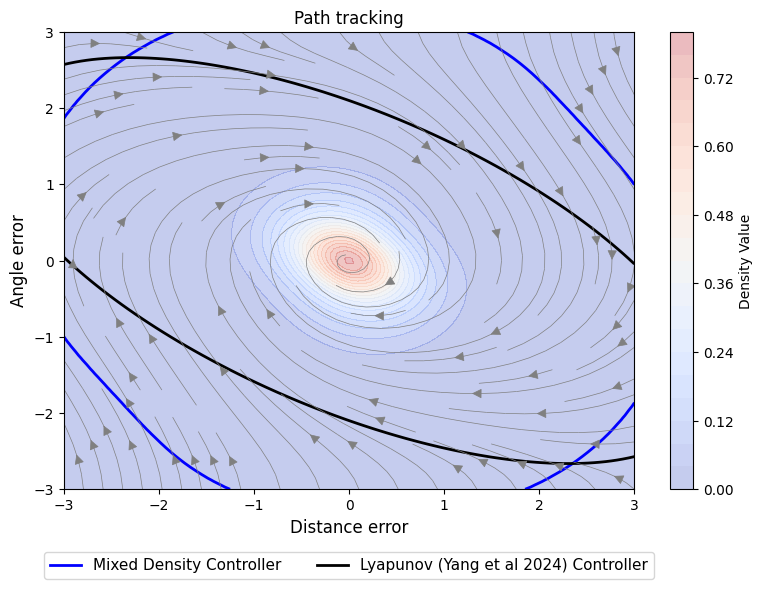

In [31]:
fig, ax = plot_mixed_density_countours_yang(a_net, b_net, c_net, a_net1, b_net1, c_net1,density_threshold=5e-7, lyapunov_yang_threshold=tau_yang2024, device=device, plot_flow=True)